In [1]:
!pip install neo4j

  Using cached neo4j-6.0.3-py3-none-any.whl.metadata (5.2 kB)
Using cached neo4j-6.0.3-py3-none-any.whl (325 kB)


In [2]:
import sys
print(sys.executable)


/Users/adrianarizk/nlp_dallard/bin/python


In [3]:
!pip show neo4j

Name: neo4j
Version: 6.0.3
Summary: Neo4j Bolt driver for Python
Home-page: https://neo4j.com/
Author: 
Author-email: "Neo4j, Inc." <drivers@neo4j.com>
License-Expression: Apache-2.0 AND Python-2.0
Location: /Users/adrianarizk/nlp_dallard/lib/python3.12/site-packages
Requires: pytz
Required-by: 


In [4]:
from neo4j import GraphDatabase

url = "bolt://localhost:7687"
username = "neo4j"
password = "password"

# Connect to Neo4j
driver = GraphDatabase.driver(url, auth=(username, password))

In [5]:
driver

Let's define a simple encapsulation function to run a cypher query into our neo4j container 

In [6]:
def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return result.to_df()


In [7]:
run_query("""
SHOW DATABASES;
"""
)

,name,type,aliases,access,address,role,writer,requestedStatus,currentStatus,statusMessage,default,home,constituents
0,neo4j,standard,[],read-write,localhost:7687,primary,True,online,online,,True,True,[]
1,system,system,[],read-write,localhost:7687,primary,True,online,online,,False,False,[]


In [8]:
run_query("""
CREATE CONSTRAINT IF NOT EXISTS FOR (s:Stream) REQUIRE s.id IS UNIQUE;
"""
)

""


In [9]:
run_query("""
LOAD CSV WITH HEADERS FROM "https://bit.ly/3JjgKgZ" AS row
MERGE (s:Stream {id: row.id})
SET s.language = row.language
"""
)

""


In [10]:
# Load the data 
# 
run_query("""
LOAD CSV WITH HEADERS FROM "https://bit.ly/3S9Uyd8" AS row
CALL{
    WITH row
    MATCH (s:Stream {id:row.source})
    MATCH (t:Stream {id:row.target})
    MERGE (s)-[r:SHARED_AUDIENCE]->(t)
    SET r.weight = toInteger(row.weight)
} IN TRANSACTIONS
""")

""


In [11]:
'''run_query("""
CALL gds.graph.drop('twitch')
""")'''

# I had put this code because when I execute twice the next cell, I may encoutner an error of type : " neo4j can't rewrite on a cell where's it's already written on "

'run_query("""\nCALL gds.graph.drop(\'twitch\')\n""")'

In [12]:
run_query("""
CALL gds.graph.project("twitch", "Stream", 
  {SHARED_AUDIENCE: {orientation: "UNDIRECTED", properties:["weight"]}})
"""
)

,nodeProjection,relationshipProjection,graphName,nodeCount,relationshipCount,projectMillis
0,"{'Stream': {'label': 'Stream', 'properties': {}}}","{'SHARED_AUDIENCE': {'aggregation': 'DEFAULT',...",twitch,3721,262854,76


In [13]:
# run query to create node2vec embeddings
run_query("""
CALL gds.beta.node2vec.write('twitch', 
  {embeddingDimension:8, relationshipWeightProperty:'weight',
   inOutFactor:0.5, returnFactor:1, writeProperty:'node2vec'})
"""
)

Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="The query used a deprecated procedure. ('gds.beta.node2vec.write' has been replaced by 'gds.node2vec.write')", position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'column': 1, 'offset': 1, 'line': 2}}> for query: "\nCALL gds.beta.node2vec.write('twitch', \n  {embeddingDimension:8, relationshipWeightProperty:'weight',\n   inOutFactor:0.5, returnFactor:1, writeProperty:'node2vec'})\n"


,nodeCount,nodePropertiesWritten,preProcessingMillis,computeMillis,writeMillis,configuration,lossPerIteration
0,3721,3721,0,4183,87,"{'writeProperty': 'node2vec', 'walkLength': 80...",[22246996.440176416]


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


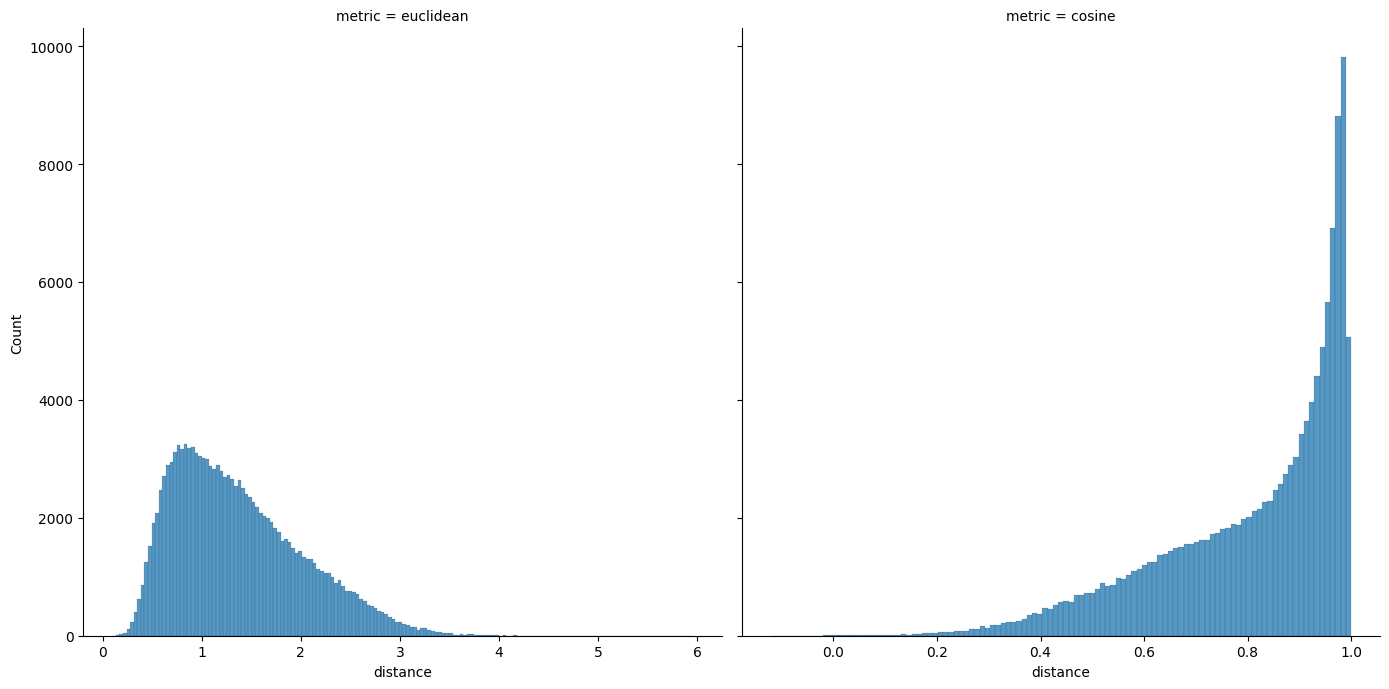

In [16]:
!pip install matplotlib
!pip install seaborn
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [16, 9]
import seaborn as sns

df = run_query("""
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
RETURN gds.similarity.euclideanDistance(
   c1.node2vec, c2.node2vec) AS distance, 'euclidean' as metric
UNION
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
RETURN gds.similarity.cosine(
   c1.node2vec, c2.node2vec) AS distance, 'cosine' as metric
"""
)

sns.displot(
    data=df,
    x="distance",
    col="metric",
    common_bins=False,
    facet_kws=dict(sharex=False),
    height=7,
)

<Axes: xlabel='cosineSimilarity', ylabel='avgDegree'>

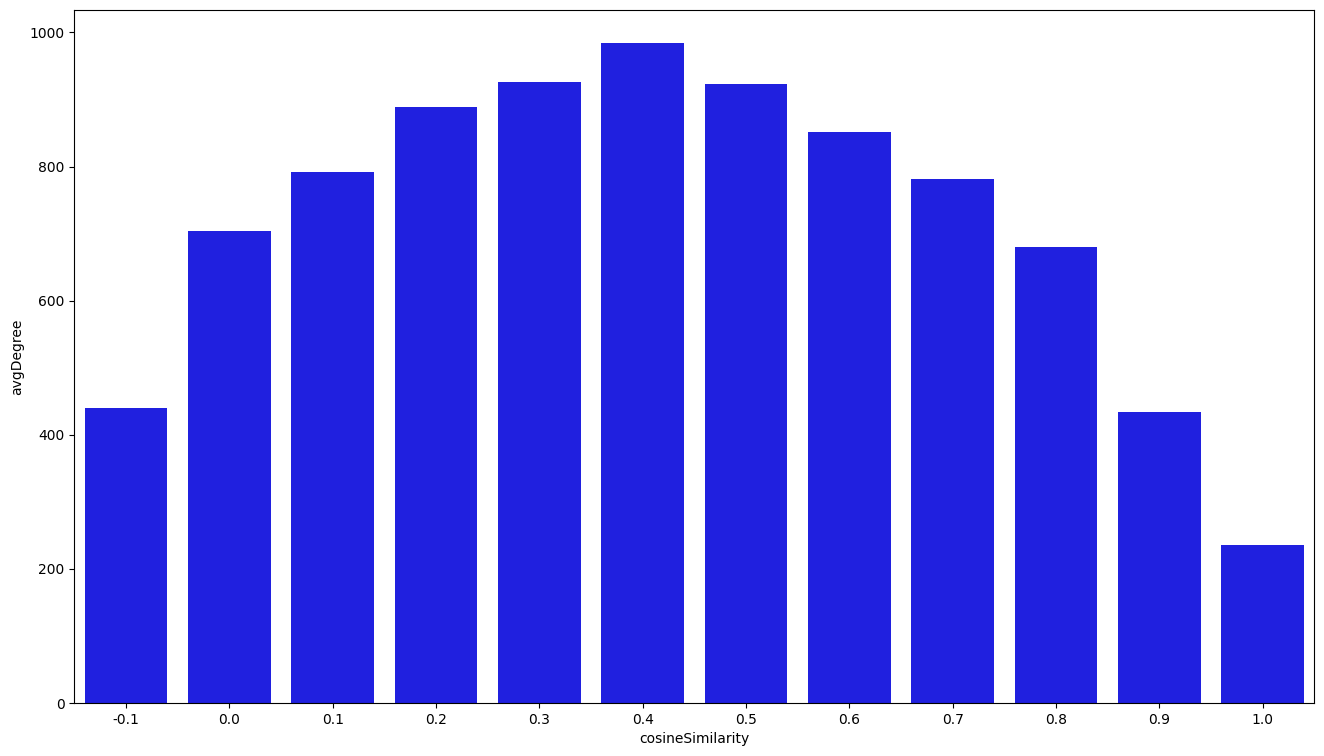

In [17]:
df = run_query("""
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
WITH c1, c2, gds.similarity.cosine(c1.node2vec, c2.node2vec) AS cosineSimilarity,
     count{ (c1)-[:SHARED_AUDIENCE]-() } AS degree1,
     count{ (c2)-[:SHARED_AUDIENCE]-() } AS degree2
RETURN round(cosineSimilarity,1) AS cosineSimilarity, avg(degree1 + degree2) AS avgDegree
ORDER BY cosineSimilarity
"""
)

sns.barplot(data=df, x="cosineSimilarity", y="avgDegree", color="blue")

<Axes: xlabel='cosineSimilarity', ylabel='avgWeight'>

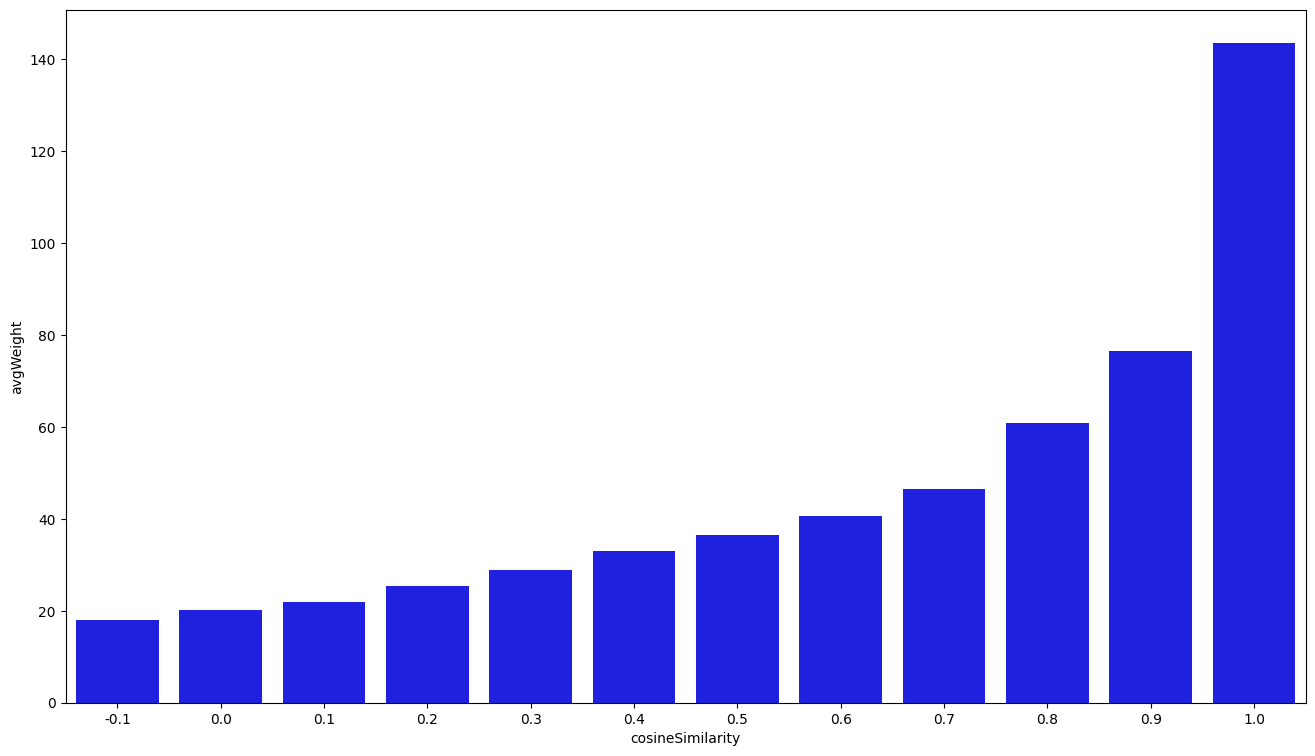

In [18]:
df = run_query("""
MATCH (c1:Stream)-[r:SHARED_AUDIENCE]->(c2:Stream)
WITH c1, c2, gds.similarity.cosine(c1.node2vec, c2.node2vec) AS cosineSimilarity,
     r.weight AS weight
RETURN round(cosineSimilarity,1) AS cosineSimilarity, avg(weight) AS avgWeight
ORDER BY cosineSimilarity
"""
)

sns.barplot(data=df, x="cosineSimilarity", y="avgWeight", color="blue")

In [19]:
import pandas as pd
data = run_query("""
MATCH (s:Stream)
RETURN s.id AS streamId, s.language AS language, s.node2vec AS embedding
"""
)
data["output"] = pd.factorize(data["language"])[0]

In [20]:
data.head()

,streamId,language,embedding,output
0,129004176,en,"[-1.6684385538101196, -0.49604249000549316, -1...",0
1,26490481,en,"[-1.3797651529312134, -0.13072288036346436, -0...",0
2,213749122,en,"[-1.4396194219589233, 0.0169172752648592, -0.7...",0
3,30104304,en,"[-1.4593368768692017, 0.32967254519462585, 0.0...",0
4,160504245,en,"[-1.4802935123443604, -0.013115479610860348, -...",0


In [23]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = data["embedding"].to_list()
y = data["output"].to_list()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

  Using cached scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.16.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl (8.6 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached scipy-1.16.3-cp312-cp312-macosx_14_0_arm64.whl (20.9 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
from sklearn.metrics import classification_report

y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       384
           1       0.94      0.87      0.90        54
           2       0.98      0.92      0.95        59
           3       0.83      0.90      0.86        39
           4       0.87      0.92      0.90        52
           5       0.88      0.86      0.87        58
           6       1.00      0.95      0.97        20
           7       0.92      0.96      0.94        25
           8       0.94      0.89      0.91        35
           9       0.90      1.00      0.95        19

    accuracy                           0.91       745
   macro avg       0.92      0.92      0.92       745
weighted avg       0.91      0.91      0.91       745



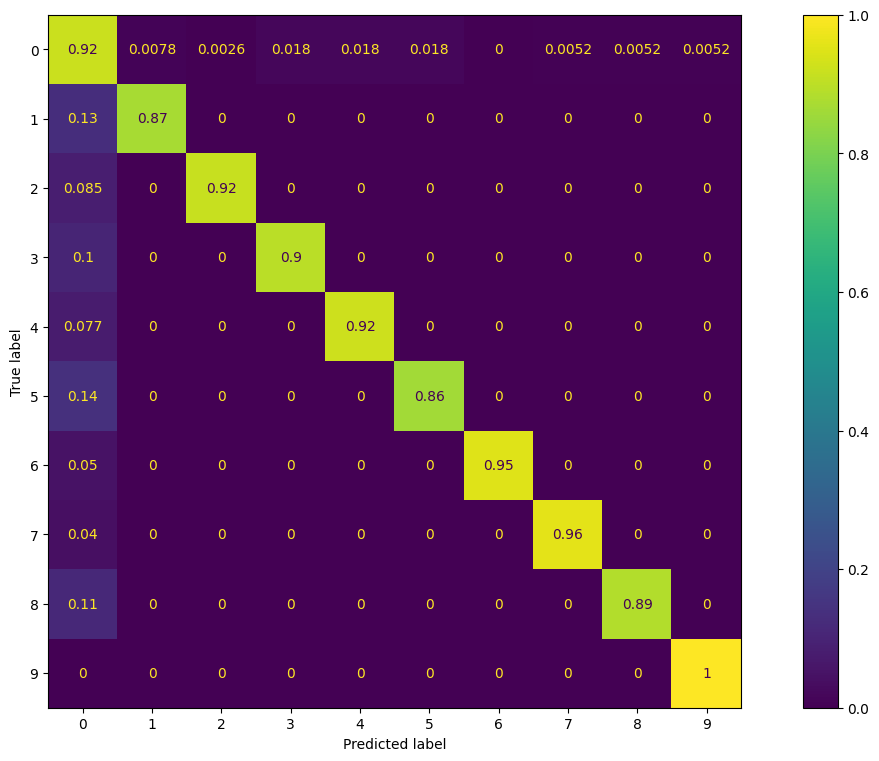

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

### What do you think about this matrix?

The confusion matrix shows a strong diagonal (0.86–1.00), with very small off-diagonal values. This indicates that the model predicts most classes correctly and does not systematically confuse specific categories. A few classes such as 0 and 5 show minor ambiguity, but overall the classifier is accurate and well-calibrated.

### What is the appropriate metrics to select among the classification report to show your manager and why ?

For a manager, I would show the overall Accuracy because it provides a simple and intuitive view of how well the model performs. I would also include the Macro F1-score, which summarizes the balance between precision and recall across all classes, especially in case of class imbalance. These two metrics together give a clear and reliable picture of the model’s performance without overwhelming a non-technical audience

### How can you improve the classifiers quality ?


To improve the classifier’s quality, I can enhance the dataset (more samples, balanced classes, cleaner labels), use stronger embeddings, try more advanced models, and tune hyperparameters. I can also analyze misclassifications and add targeted examples to help the model generalize better.